In [1]:
!pip install numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
class Perceptron:
  def __init__(self, alpha=0.1, epoch=10):
    self.alpha = alpha
    self.epoch = epoch
  def weighted_sum(self, X):
    return np.dot(X, self.w_[1:]) + self.w_[0]
  def predict(self, X):
    return np.where(self.weighted_sum(X) >= 0.0, 1, -1)
  def plot_decision_boundary(self, X, t, epoch):
    plt.scatter(X[:, 0], X[:, 1], c=t.ravel(), marker='o',
    edgecolors='k', cmap=plt.cm.RdYlBu)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x_vals = np.linspace(x_min, x_max, 100)
    y_vals = -(self.w_[0] + self.w_[1] * x_vals) / self.w_[2]
    plt.plot(x_vals, y_vals, 'b-', label=f'Decision boundary (Epoch{epoch+1})')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title(f"Decision Boundary Pada Epoch {epoch+1}")
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.show()
  def fit(self, X, t):
    self.w_ = np.zeros(1 + X.shape[1])
    with open("HasilPerceptron.txt", "w") as f:
      f.write("Masalah OR dengan Perceptron\n")
      f.write("----------------------------\n")
      f.write(f"Input :\n{X}\n")
      f.write(f"Target:\n{t}\n")
      f.write(f"Bobot awal : {self.w_[1:]}\n")
      f.write(f"Bias awal : {self.w_[0]}\n")
      f.write(f"Learning rate : {self.alpha}\n")
      f.write(f"Max Epoch : {self.epoch}\n")
      f.write("----------------------------\n")
      for epoch in range(self.epoch):
        f.write(f"\nEpoch {epoch + 1}/{self.epoch}\n")
        f.write("----------\n")
        error = np.array([])
        for xi, target in zip(X, t):
          y_pred = self.predict(xi)
          error = np.append(error, target - y_pred)
          update = self.alpha * error[-1]
          self.w_[1:] += update * xi
          self.w_[0] += update
          f.write(f"Input: {xi}, Target: {target}, Predict: {y_pred}, Error: {error[-1]}, Bobot: {self.w_[1:]}, Bias: {self.w_[0]}\n")
        self.plot_decision_boundary(X, t, epoch)
        f.write(f"Sum Square Error(SSE): {sum(error ** 2)}\n")
        if sum(error ** 2) == 0 or epoch + 1 == self.epoch:
          f.write("--------------------------------------------------------------------------------\n")
          f.write(f"Pelatihan berhenti pada epoch ke-{epoch + 1} karena ")
          f.write("Sum Square Error(SSE) mencapai target.\n" if epoch + 1 != self.epoch else "max epoch tercapai.\n")
          f.write(f"\nBobot akhir :{self.w_[1:]}\n")
          f.write(f"Bias akhir :{self.w_[0]}")
          break





In [41]:
class Backpropagation:
  def __init__(self, alpha, epoch, target_error):
    self.alpha = alpha
    self.epoch = epoch
    self.target_error = target_error
    self.n_input = 2
    self.n_hidden = 2
    self.n_output = 1
    self.w_hidden = np.random.rand(self.n_input, self.n_hidden)
    self.b_hidden = np.random.rand(1, self.n_hidden)
    self.w_output = np.random.rand(self.n_hidden, self.n_output)
    self.b_output = np.random.rand(1, self.n_output)
  def bi_sigmoid(self, x):
    return np.tanh(x)
  def deriv_bi_sigmoid(self, x):
    return 1 - x**2
  def plot_error(self, x, epoch):
    plt.plot(range(1, epoch + 1), x, linestyle='-', color='b', label='Error')
    final_error = x[-1]
    plt.annotate(f'Epoch {epoch}, Error: {final_error:.4f}', xy=(epoch, final_error), xytext=(epoch - len(x) * 0.2, final_error + 0.05), arrowprops=dict(facecolor='black', arrowstyle="->"), fontsize=10, color='red')
    plt.title('Perbaikan Error Setiap Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Sum Square Error(SSE)')
    plt.grid(True)
    plt.legend()
    plt.show()
  def fit(self, X, t):
    errors_per_epoch = []
    with open("hasilBackpropagation.txt", "w") as f:
      f.write("Masalah XOR dengan Backpropagation\n")
      f.write("-----------------------------------\n")
      f.write(f"Input :\n{X}\n")
      f.write(f"Target :\n{t}\n\n")
      f.write(f"Bobot awal hidden layer :\n{self.w_hidden}\n\n")
      f.write(f"Bias awal hidden layer :\n{self.b_hidden}\n\n")
      f.write(f"Bobot awal output layer :\n{self.w_output}\n\n")
      f.write(f"Bias awal output layer :\n{self.b_output}\n\n")
      f.write(f"Learning rate : {self.alpha}\n")
      f.write(f"Max Epoch : {self.epoch}\n\n")
      for epoch in range(self.epoch):
        f.write("---------------------------------------------\n")
        f.write(f"Epoch {epoch + 1}/{self.epoch}\n")
        f.write("------------\n")
        total_error = 0
        count = 1
        output = np.array([])
        for xi, target in zip(X, t):
          f.write(f"Data ke-{count}\n")
          f.write("----------\n")
          f.write("------------ Forward Propagation------------\n")
          h_in = np.dot(xi, self.w_hidden) + self.b_hidden
          f.write(f"Operasi input ke hidden layer:\n{h_in}\n\n")
          h = self.bi_sigmoid(h_in)
          f.write(f"Aktivasi hidden layer:\n{h}\n\n")
          y_in = np.dot(h, self.w_output) + self.b_output
          f.write(f"Operasi hidden ke output layer:\n{y_in}\n\n")
          y = self.bi_sigmoid(y_in)
          output = np.append(output, y)
          f.write(f"Aktivasi output layer:\n{y}\n")
          f.write("------------ Backward Propagation------------\n")
          error = target - y
          total_error += np.sum(error**2)
          f.write(f"Error:\n{error}\n\n")
          d_y = error * self.deriv_bi_sigmoid(y)
          f.write(f"Delta output (d_y):\n{d_y}\n\n")
          error_h = np.dot(d_y, self.w_output.T)
          f.write(f"Error hidden layer (error_h):\n{error_h}\n\n")
          d_h = error_h * self.deriv_bi_sigmoid(h)
          f.write(f"Delta hidden layer (d_h):\n{d_h}\n\n")
          self.w_output += np.dot(h.T, d_y) * self.alpha
          f.write(f"Bobot output layer baru (w_output):\n{self.w_output}\n\n")
          self.b_output += np.sum(d_y, axis=0, keepdims=True) * self.alpha
          f.write(f"Bias output layer baru (b_output):\n{self.b_output}\n\n")
          self.w_hidden += np.dot(xi.reshape(2,1), d_h) * self.alpha
          f.write(f"Bobot hidden layer baru (w_hidden):\n{self.w_hidden}\n\n")
          self.b_hidden += np.sum(d_h, axis=0, keepdims=True) * self.alpha
          f.write(f"Bias hidden layer baru (b_hidden):\n{self.b_hidden}\n")
          f.write("---------------------------------------------\n")
          count += 1
        average_error = total_error / len(X)
        errors_per_epoch.append(average_error)
        f.write(f"Output : {output.reshape(1,4)}\n")
        f.write(f"Sum Square Error(SSE) epoch ke-{epoch + 1}: {average_error}\n")
        if average_error < self.target_error or epoch + 1 == self.epoch:
          f.write("----------------------------------------------------------------------------------\n")
          f.write(f"Pelatihan berhenti pada epoch ke-{epoch + 1} karena ")
          f.write("Sum Square Error(SSE) mencapai target.\n" if epoch + 1 != self.epoch else "max epoch tercapai.\n")
          f.write(f"Bobot akhir hidden layer:\n{self.w_hidden}\n\n")
          f.write(f"Bias akhir hidden layer:\n{self.b_hidden}\n\n")
          f.write(f"Bobot akhir output layer:\n{self.w_output}\n\n")
          f.write(f"Bias akhir output layer :\n{self.b_output}")
          self.plot_error(errors_per_epoch, epoch + 1)
          break








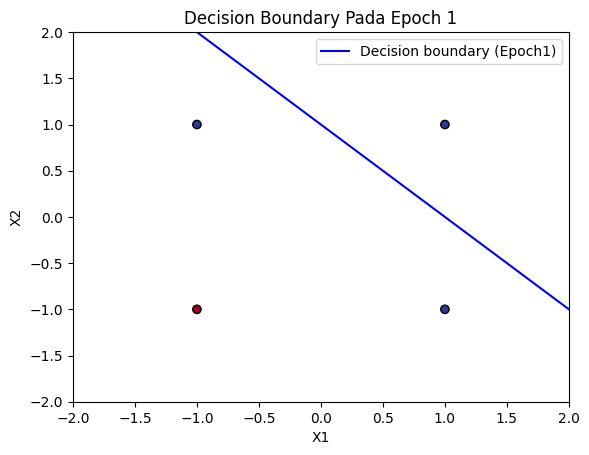

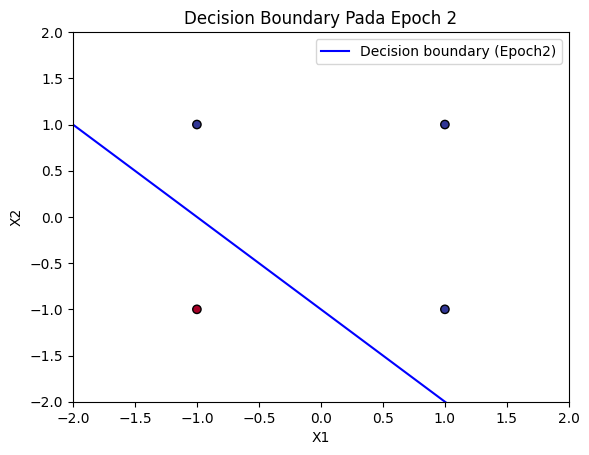

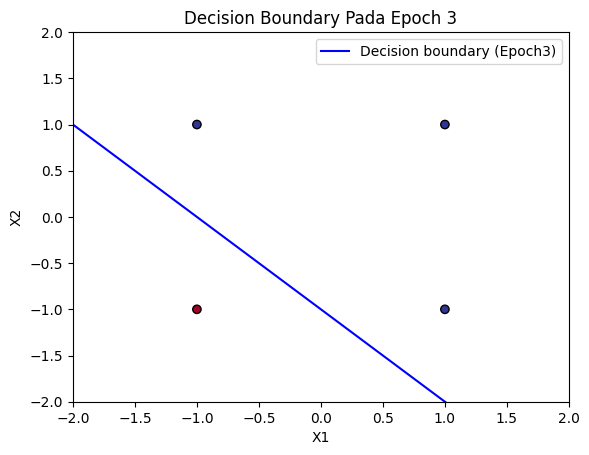

In [54]:
X = np.array([[1,1], [1,-1], [-1,1], [-1,-1]])
t = np.array([[1], [1], [1], [-1]])

model = Perceptron(alpha=0.1, epoch=10)
model.fit(X, t)


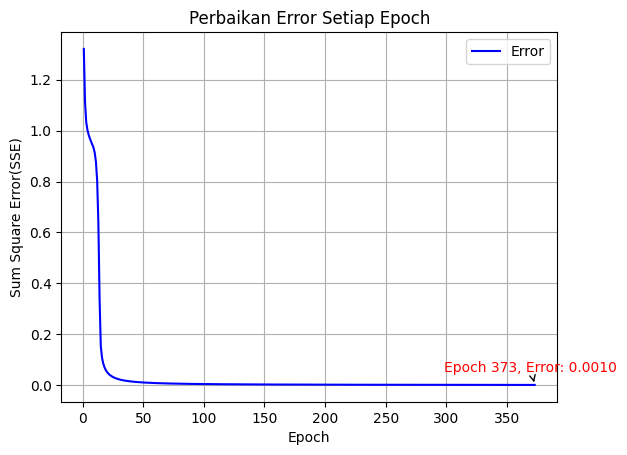

In [74]:
Y = np.array([[1, 1], [1, -1], [-1, 1], [-1, -1]])
u = np.array([[-1], [1], [1], [-1]])

model = Backpropagation(alpha=0.3, epoch=1000, target_error=0.001)
model.fit(Y, u)
